<a href="https://colab.research.google.com/github/rgulamali/AIMAppForAPI/blob/master/ReadCSVCalMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
i need to read a csv file from C:\DownloadNew\AlpacaTrading


SyntaxError: invalid syntax (3827545561.py, line 1)

In [12]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving SPY_close_price_5Y.csv to SPY_close_price_5Y (1).csv
User uploaded file "SPY_close_price_5Y (1).csv" with length 23739 bytes


After uploading, you can read the file into a pandas DataFrame. Remember to replace `your_file_name.csv` with the exact name of the file you uploaded.

In [13]:
import pandas as pd

# Replace 'your_file_name.csv' with the actual name of your uploaded CSV file
df = pd.read_csv('SPY_close_price_5Y.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Date,Close
0,2020-11-02,330.20
1,2020-11-03,336.03
2,2020-11-04,343.54
3,2020-11-05,350.24
4,2020-11-06,350.16


First, let's ensure the 'Date' column is in datetime format and sort the DataFrame by date, which is crucial for accurate moving average calculations.

In [15]:
df.assign(
    ma_50=lambda d: d.Close.rolling(window=50, min_periods=50).mean(),
    ma_200=lambda d: d.Close.rolling(window=200, min_periods=200).mean(),
    gc=lambda d: ((d.ma_50 > d.ma_200) & (d.ma_50.shift(1) <= d.ma_200.shift(1))).astype(int)
).query("gc==1")

,Date,Close,ma_50,ma_200,gc
566,2023-02-02,416.78,394.3504,394.25025,1
1169,2025-07-01,617.65,583.0978,582.04155,1


Let's first define the 'gc' (golden cross) column in your DataFrame. A golden cross occurs when the 50-day moving average crosses above the 200-day moving average.

First, let's ensure the 'Date' column is in datetime format and sort the DataFrame by date, which is crucial for accurate moving average calculations. Then, we will explicitly add the `MA_50`, `MA_200`, and `gc` (golden cross) columns to your `df` DataFrame.

In [20]:
import pandas as pd

# Ensure 'Date' column is datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Sort the DataFrame by 'Date' to ensure correct moving average calculation
df = df.sort_values(by='Date').reset_index(drop=True)

# Calculate 50-day Moving Average
df['MA_50'] = df['Close'].rolling(window=50, min_periods=1).mean()

# Calculate 200-day Moving Average
df['MA_200'] = df['Close'].rolling(window=200, min_periods=1).mean()

# Calculate the 'gc' (golden cross) indicator
# A golden cross occurs when MA_50 crosses above MA_200.
# This checks if MA_50 was less than or equal to MA_200 on the previous day,
# and is now greater than MA_200 on the current day.
df['gc'] = ((df['MA_50'].shift(1) <= df['MA_200'].shift(1)) & (df['MA_50'] > df['MA_200'])).astype(int)

# Display the DataFrame with the new columns, showing the relevant part
display(df[['Date', 'Close', 'MA_50', 'MA_200', 'gc']].tail(10))

,Date,Close,MA_50,MA_200,gc
1246,2025-10-20,671.30,655.3516,605.32820,0
1247,2025-10-21,671.29,656.0590,605.76145,0
1248,2025-10-22,667.80,656.5612,606.14070,0
1249,2025-10-23,671.76,657.0986,606.52270,0
1250,2025-10-24,677.25,657.7446,606.96580,0
1251,2025-10-27,685.24,658.5806,607.44455,0
1252,2025-10-28,687.06,659.4558,607.97740,0
1253,2025-10-29,687.39,660.4074,608.50740,0
1254,2025-10-30,679.83,661.2418,608.99560,0
1255,2025-10-31,682.06,662.1720,609.44200,0


Now that the columns are properly added to the `df` DataFrame, let's visualize the 'Close' price, 50-day Moving Average, 200-day Moving Average, and highlight the golden cross points.

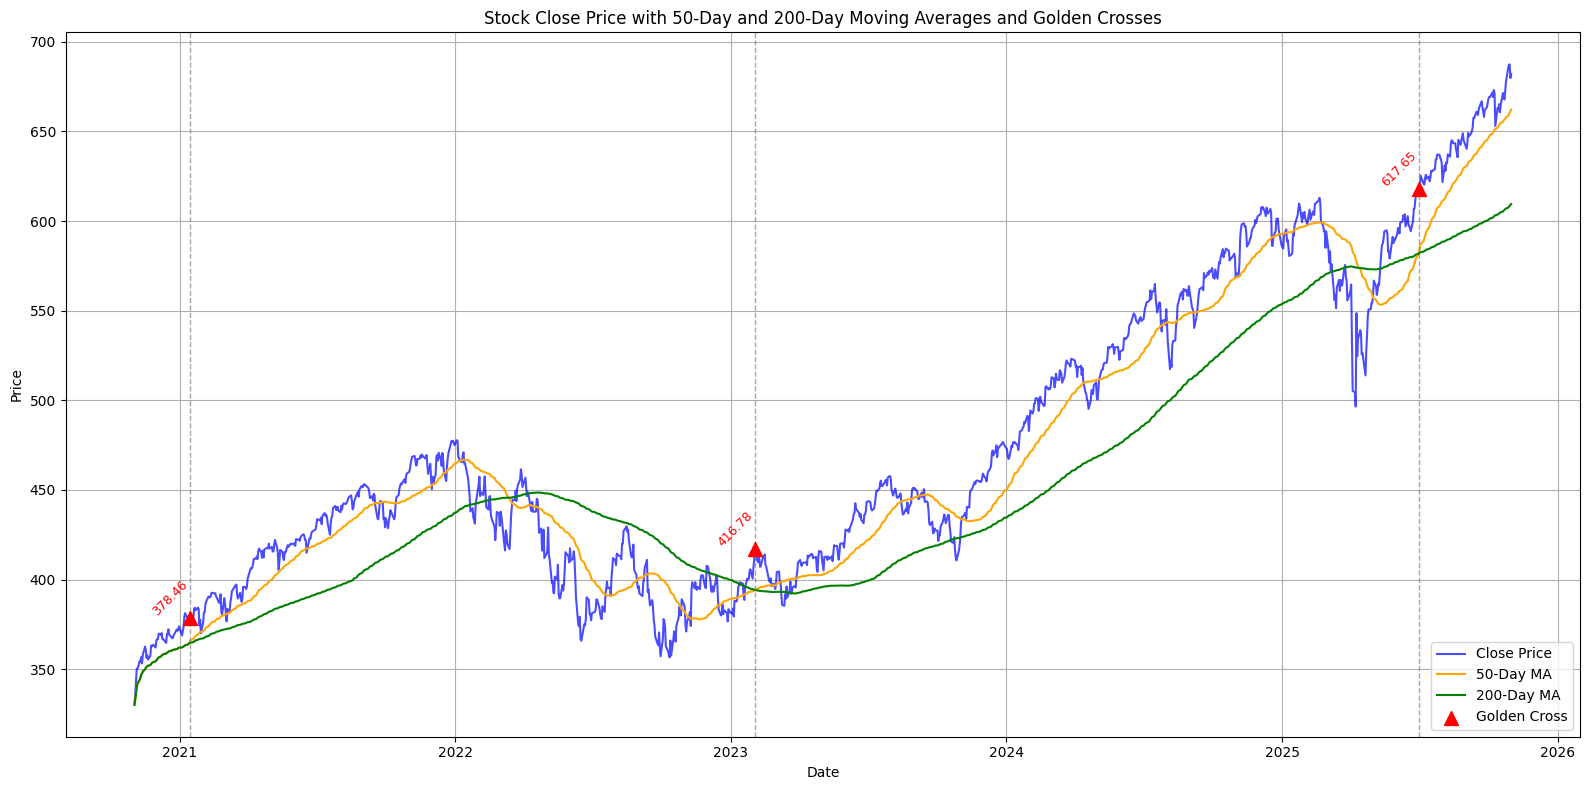

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability of the plot
plt.figure(figsize=(16, 8))

# Plot the 'Close Price' as a blue line with some transparency
sns.lineplot(x='Date', y='Close', data=df, label='Close Price', color='blue', alpha=0.7)
# Plot the 50-day Moving Average as an orange line
sns.lineplot(x='Date', y='MA_50', data=df, label='50-Day MA', color='orange')
# Plot the 200-day Moving Average as a green line
sns.lineplot(x='Date', y='MA_200', data=df, label='200-Day MA', color='green')

# Identify golden cross points where 'gc' column is 1
golden_cross_points = df[df['gc'] == 1]
# Mark these golden cross points on the plot using red upward-pointing triangles
plt.scatter(golden_cross_points['Date'], golden_cross_points['Close'],
            color='red', marker='^', s=100, zorder=5, label='Golden Cross')

# Loop through each golden cross point to add vertical lines and text annotations
for index, row in golden_cross_points.iterrows():
    # Add a dashed gray vertical line at the date of the golden cross
    plt.axvline(x=row['Date'], color='gray', linestyle='--', linewidth=1, alpha=0.7)
    # Add text annotation for the 'Close' price at the golden cross point
    plt.text(row['Date'], row['Close'], f'{row['Close']:.2f}',
             verticalalignment='bottom', horizontalalignment='right',
             color='red', fontsize=9, rotation=45)

# Set the title of the plot
plt.title('Stock Close Price with 50-Day and 200-Day Moving Averages and Golden Crosses')
# Set the x-axis label
plt.xlabel('Date')
# Set the y-axis label
plt.ylabel('Price')
# Display the legend to identify each line and marker
plt.legend()
# Add a grid to the plot for better readability
plt.grid(True)
# Adjust plot layout to prevent labels from overlapping
plt.tight_layout()
# Show the plot
plt.show()